---
title: "Conditional flow as an amortised posterior"
short_title: "02 · Amortised posterior"
subtitle: "Train a conditional flow on (x, y=Ax+η) pairs once, and it becomes the posterior p(x|y) for an inverse problem — one forward pass per observation, bimodal when the data underdetermines x"
description: >
  An inverse problem asks for x given a noisy, possibly underdetermined observation
  y = A x + η. A conditional flow trained on simulated (x, y) pairs learns the
  amortised posterior p(x|y): train once, then sample or score the posterior for any y
  in a single pass — no per-observation optimisation or MCMC. This notebook builds the
  toy on a two-moons prior with a 1-D observation, checks the flow posterior against a
  rejection-sampled reference (including a bimodal case), verifies observation
  consistency, and points at the plug-and-play inverse solvers of Part 16.
---

(sec-nb-cond-02)=
# 02 — Conditional flow as an amortised posterior

An **inverse problem** observes $y = A x + \eta$ — a linear measurement of a hidden
$x$, blurred by noise $\eta\sim\mathcal{N}(0,\sigma^2 I)$ — and asks for $x$. When $A$
loses information (here $A:\mathbb{R}^2\to\mathbb{R}^1$), many $x$ explain the same
$y$, so the answer is a **posterior** $p(x\mid y)\propto p(y\mid x)\,p(x)$, not a point.

A conditional flow is a natural fit. Simulate pairs $(x, y)$ with $x\sim p(x)$ and
$y = Ax+\eta$, then train $p_\theta(x\mid y)$ by the conditional NLL of notebook
[01](01_conditional_density.ipynb). The result is an **amortised** posterior
{cite}`papamakarios2021nf`, {cite}`winkler2019cnf`: the cost of inference is paid once
at training time, and afterwards *any* observation $y$ yields posterior samples and
densities in a single forward pass — no per-$y$ optimisation, no MCMC chain. Because
the flow is fully expressive, the posterior can be **multimodal** when the observation
genuinely underdetermines $x$ — something a Gaussian/Laplace approximation cannot do.

**What you will see**

- A two-moons **prior** and a 1-D observation $y = x_1 + x_2 + \eta$.
- One conditional flow trained on simulated $(x, y)$ pairs.
- The **amortised posterior** for several $y$, against a rejection-sampled reference —
  including a **bimodal** posterior the flow recovers.
- **Observation consistency**: pushing posterior samples back through $A$ recenters on $y$.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from flowjax.bijections import Chain, Permute
from flowjax.distributions import Normal, Transformed
from flowjax.train import fit_to_data
from sklearn.datasets import make_moons

from gauss_flows import RQSplineCoupling
from _style import DATA_COLOR, LATENT_COLOR, SCATTER_KW, style_ax

jax.config.update("jax_enable_x64", True)

## 1. The forward model: two-moons prior + a 1-D observation

The prior $p(x)$ is the standardised two moons. The forward operator $A = [1, 1]$
collapses the plane onto the anti-diagonal, $y = x_1 + x_2$, with Gaussian noise
$\sigma = 0.1$. An observation $y$ therefore pins $x$ to a *line* $x_1 + x_2 \approx y$
— and the posterior is the slice of the moons that line cuts through.

prior X (6000, 2), observation Y (6000, 1); y = x1 + x2 + N(0,0.1^2)


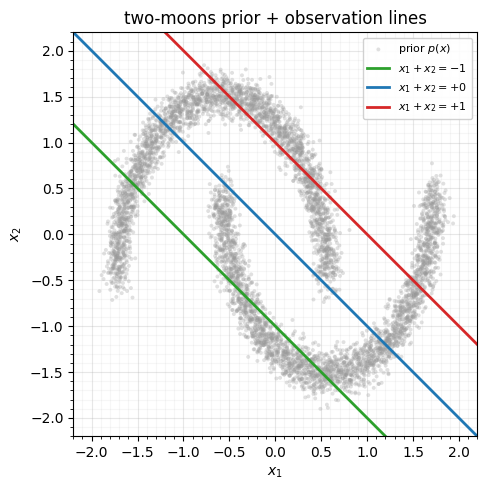

In [2]:
A = jnp.array([[1.0, 1.0]])  # (1, 2) observation operator
SIGMA = 0.1


def sample_prior(key, n):
    x, _ = make_moons(n_samples=n, noise=0.06, random_state=int(jr.randint(key, (), 0, 1_000_000)))
    return jnp.asarray(x)


_pilot = sample_prior(jr.key(99), 20000)
X_MEAN, X_STD = _pilot.mean(0), _pilot.std(0)


def prior(key, n):
    return (sample_prior(key, n) - X_MEAN) / X_STD


def observe(key, x):
    return x @ A.T + SIGMA * jr.normal(key, (x.shape[0], 1))


kx, ky = jr.split(jr.key(0))
X = prior(kx, 6000)
Y = observe(ky, X)
print(f"prior X {X.shape}, observation Y {Y.shape}; y = x1 + x2 + N(0,{SIGMA}^2)")

y_demo = [-1.0, 0.0, 1.0]
fig, ax = plt.subplots(figsize=(5.6, 5))
ax.scatter(np.asarray(X[:, 0]), np.asarray(X[:, 1]), s=8, alpha=0.3, color="0.6",
           edgecolors="none", label="prior $p(x)$")
xs = np.linspace(-2.5, 2.5, 10)
for yv, col in zip(y_demo, ("tab:green", DATA_COLOR, "tab:red")):
    ax.plot(xs, yv - xs, color=col, lw=2, label=f"$x_1+x_2={yv:+.0f}$")
ax.set(title="two-moons prior + observation lines", xlabel="$x_1$", ylabel="$x_2$",
       xlim=(-2.2, 2.2), ylim=(-2.2, 2.2))
ax.set_aspect("equal"); ax.legend(fontsize=8, framealpha=0.9); style_ax(ax)
fig.tight_layout()

Each line is one observation. Where it crosses **one** crescent the posterior is a
single blob; where it crosses **both**, the posterior is bimodal — watch the $y=0$
(anti-diagonal) line, which clips both moons.

## 2. Train the amortised posterior

A conditional coupling flow $p_\theta(x\mid y)$ (fixed $\mathcal{N}(0,I)$ base,
`RQSplineCoupling(cond_dim=1)` reading the scalar observation) trained by NLL on the
simulated pairs. One run; the posterior for every $y$ comes for free afterwards.

In [3]:
def make_flow(key, n_layers=6):
    keys = jr.split(key, n_layers)
    perm = jnp.array([1, 0])
    tr = []
    for i, k in enumerate(keys):
        tr.append(RQSplineCoupling(k, shape=(2,), n_bins=8, interval=5.0,
                                   cond_dim=1, nn_width=64, nn_depth=2))
        if i < n_layers - 1:
            tr.append(Permute(perm))
    return Transformed(Normal(jnp.zeros(2)), Chain(tr))


steps = -(-int(X.shape[0] * 0.9) // 256)
lr = optax.cosine_decay_schedule(3e-3, decay_steps=350 * steps, alpha=0.02)
opt = optax.chain(optax.clip_by_global_norm(5.0), optax.adam(lr))
post, losses = fit_to_data(jr.key(1), make_flow(jr.key(2)), (X, Y), optimizer=opt,
                           max_epochs=350, max_patience=350, batch_size=256,
                           val_prop=0.1, show_progress=False)
print(f"trained amortised posterior: {len(losses['train'])} epochs, "
      f"val NLL {float(min(losses['val'])):+.4f}")

trained amortised posterior: 350 epochs, val NLL -0.8465


## 3. The amortised posterior vs a rejection reference

For each observation $y$ we compare two posteriors. The **reference** is rejection
sampling on the prior — keep prior draws whose $Ax$ falls within a hair of $y$ — which
is exact but throws away almost every sample. The **flow** posterior is one batched
`sample(condition=y)` call. They should agree, and the flow should recover the bimodal
$y=0$ case.

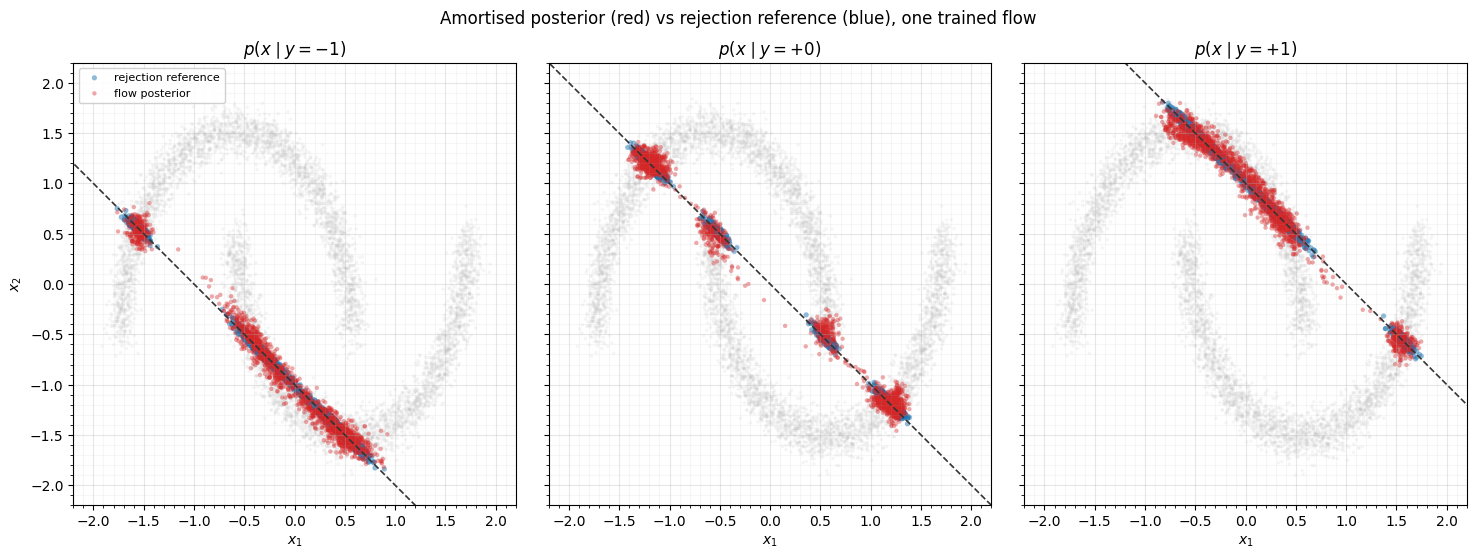

In [4]:
def reject_posterior(key, yv, tol=0.06, n_keep=1500):
    big = prior(key, 300000)
    resid = jnp.abs((big @ A.T)[:, 0] - yv)
    return big[resid < tol][:n_keep]


def flow_posterior(yv, n, key):
    c = jnp.array([yv])
    return jax.vmap(lambda k: post.sample(k, condition=c))(jr.split(key, n))


fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharex=True, sharey=True)
xs = np.linspace(-2.5, 2.5, 10)
for ax, yv in zip(axes, y_demo):
    ref = reject_posterior(jr.fold_in(jr.key(5), int((yv + 2) * 10)), yv)
    fs = flow_posterior(yv, 1500, jr.fold_in(jr.key(6), int((yv + 2) * 10)))
    ax.scatter(np.asarray(X[:, 0]), np.asarray(X[:, 1]), s=6, alpha=0.12, color="0.7", edgecolors="none")
    ax.scatter(np.asarray(ref[:, 0]), np.asarray(ref[:, 1]), s=14, alpha=0.5, color=DATA_COLOR,
               edgecolors="none", label="rejection reference")
    ax.scatter(np.asarray(fs[:, 0]), np.asarray(fs[:, 1]), s=10, alpha=0.4, color="tab:red",
               edgecolors="none", label="flow posterior")
    ax.plot(xs, yv - xs, color="0.2", lw=1.2, ls="--")
    ax.set(title=f"$p(x \\mid y={yv:+.0f})$", xlabel="$x_1$", xlim=(-2.2, 2.2), ylim=(-2.2, 2.2))
    ax.set_aspect("equal"); style_ax(ax)
axes[0].set_ylabel("$x_2$")
axes[0].legend(loc="upper left", fontsize=8, framealpha=0.9)
fig.suptitle("Amortised posterior (red) vs rejection reference (blue), one trained flow", y=1.01)
fig.tight_layout()

The flow posteriors sit on the moons, hug the observation line, and at $y=0$ the flow
splits into **two modes** — one per crescent — matching the reference. All three come
from the *same* network, evaluated at three different $y$.

## 4. Observation consistency

A correct posterior must be consistent with the measurement: pushing posterior samples
back through $A$ should recenter on the observed $y$ with spread $\approx\sigma$. We
histogram $A\hat x$ for the flow samples at each $y$.

y=-1:  mean(Ax)=-1.007 (target -1.0),  std(Ax)=0.099 (target 0.1)


y=+0:  mean(Ax)=+0.005 (target +0.0),  std(Ax)=0.105 (target 0.1)


y=+1:  mean(Ax)=+0.993 (target +1.0),  std(Ax)=0.103 (target 0.1)


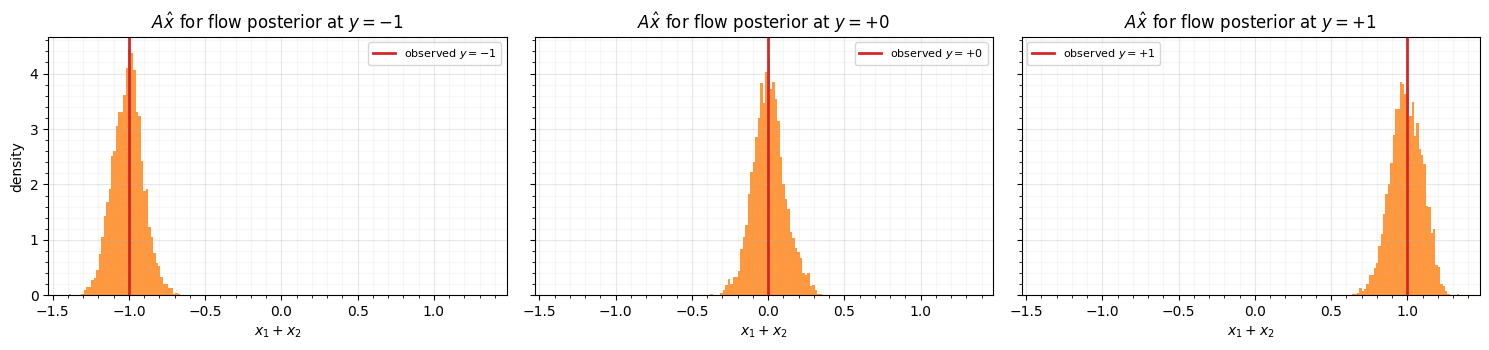

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharex=True, sharey=True)
for ax, yv in zip(axes, y_demo):
    fs = flow_posterior(yv, 4000, jr.fold_in(jr.key(8), int((yv + 2) * 10)))
    Ax = np.asarray((fs @ A.T)[:, 0])
    ax.hist(Ax, bins=45, density=True, color=LATENT_COLOR, alpha=0.8)
    ax.axvline(yv, color="tab:red", lw=2, label=f"observed $y={yv:+.0f}$")
    ax.set(title=f"$A\\hat x$ for flow posterior at $y={yv:+.0f}$", xlabel="$x_1+x_2$")
    ax.legend(fontsize=8); style_ax(ax)
    print(f"y={yv:+.0f}:  mean(Ax)={Ax.mean():+.3f} (target {yv:+.1f}),  std(Ax)={Ax.std():.3f} (target {SIGMA})")
axes[0].set_ylabel("density")
fig.tight_layout()

The reprojected samples center on $y$ with standard deviation close to the noise
$\sigma$ — the flow learned the likelihood, not just the prior support.

## Recap — and the end of Part 7

| | amortised flow posterior (here) | classical inversion |
|---|---|---|
| cost per new $y$ | one forward pass | an optimisation / MCMC run |
| training | once, on simulated $(x,y)$ | none (but solve every time) |
| multimodal posteriors | yes, by construction | needs many restarts / chains |
| needs the forward model | only to *simulate* pairs | explicitly, every solve |

A conditional flow turns inference into amortisation: simulate $(x, y=Ax+\eta)$, fit
$p_\theta(x\mid y)$ once, and read off the posterior — bimodal and all — for any
observation in a single pass. This closes Part 7: from *where* to inject context
([00](00_three_ways_to_condition.ipynb)), through conditional density estimation and
the marginals-vs-couplings rule ([01](01_conditional_density.ipynb)), to conditioning
**on an observation** for inverse problems.

**Where this goes next.** When the prior is itself a (Gaussianization) flow rather than
something we can simulate from cheaply, the amortised route is replaced by a
**plug-and-play** scheme that alternates a data-fit step with the flow prior's
closed-form proximal/Gaussianization step — the subject of **Part 16**. The toy here
is the amortised counterpart of those solvers.